In [1]:
# PROJECT : 양자컴퓨터 기초 프로그램 실습

### 1. Bell State 복습: 2큐비트 얽힘의 수학적 이해

본격적으로 GHZ 상태를 다루기에 앞서, 가장 기본적인 얽힘 상태인 벨 상태(Bell State)를 수학적으로 복습합니다.

##### 1.1 벨 상태의 정의

가장 대표적인 벨 상태인 $|\Phi^+\rangle$는 다음과 같이 정의됩니다.

$$|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$

##### 1.2 게이트 연산 과정

Hadamard (H) 게이트 적용: 첫 번째 큐비트를 중첩 상태로 만듭니다.$$H|0\rangle \otimes |0\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) \otimes |0\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |10\rangle)$$CNOT (CX) 게이트 적용: 첫 번째 큐비트를 제어로, 두 번째를 대상으로 연산합니다.$$CNOT \left( \frac{1}{\sqrt{2}}(|00\rangle + |10\rangle) \right) = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$

##### 1.3 물리적 의미

해당 상태는 두 큐비트가 상관관계(Correlation)를 가진 상태입니다. 첫 번째 큐비트를 측정하여 $0$이 나오면, 두 번째 큐비트의 상태는 측정 전임에도 불구하고 즉시 $|0\rangle$으로 확정됩니다. 고전적인 확률 통계로는 설명할 수 없는 양자 역학의 고유한 특성입니다.

### 2. 이론: 벨 상태를 넘어 GHZ 상태로

벨 상태가 2개의 입자를 연결한다면, GHZ(Greenberger-Horne-Zeilinger) 상태는 $N$개로 확장한 다체 얽힘(Multi-particle Entanglement) 상태입니다.

##### 2.1 상태 정의

$N$개의 큐비트에 대한 GHZ 상태는 다음과 같이 정의됩니다.$$|\psi_{GHZ}\rangle = \frac{1}{\sqrt{2}}(|00...0\rangle + |11...1\rangle)$$

##### 2.2 생성 원리 (Entanglement Cascade)

GHZ 상태는 하나의 중첩을 전체 시스템으로 전파하는 방식으로 생성됩니다.

- Step 1 (중첩): $q_0$에 $H$ 게이트를 적용하여 $|0\rangle + |1\rangle$ 상태를 생성합니다.

- Step 2 (전파): $q_0$와 $q_1$을 $CX$로 연결하고, 다시 $q_1$과 $q_2$를 $CX$로 연결하는 계단식(Cascade) 구조를 통해 모든 큐비트를 하나로 묶습니다.

### 3. 왜 GHZ State가 중요한가?
 
GHZ 상태는 단순히 큐비트 수를 늘린 것을 넘어, 양자 컴퓨터가 실질적인 연산을 수행하기 위해 반드시 극복해야 할 과제들을 담고 있습니다.

##### 3.1 다체 얽힘의 제어와 확장성 
 
실제 유용한 양자 알고리즘(예: Shor 알고리즘)을 실행하려면 수백, 수천 개의 큐비트를 동시에 제어해야 합니다. GHZ 상태를 안정적으로 생성하고 유지할 수 있다는 것은, 다수의 큐비트를 하나의 시스템처럼 동작시키는 제어 기술을 확보했음을 의미합니다.

##### 3.2 양자 오류 수정(QEC)의 물리적 기초
 
양자 정보는 외부 노이즈에 매우 취약하여 쉽게 붕괴됩니다. 이를 방지하기 위해 하나의 '논리적 큐비트(Logical Qubit)' 정보를 여러 개의 물리적 큐비트에 나누어 저장하는 중복성이 필요한데, GHZ의 $|00...0\rangle + |11...1\rangle$ 구조는 이러한 에러 교정 코드(예: Repetition Code)의 가장 기본적인 형태를 제공합니다.

##### 3.3 양자 인터넷과 분산 컴퓨팅
 
미래의 양자 시스템은 단일 칩을 넘어 여러 양자 노드가 연결된 형태가 될 것입니다. 이때 멀리 떨어진 노드들이 하나의 GHZ 상태를 공유함으로써 양자 원격 전송이나 얽힘 교환을 수행할 수도 있으며, 분산 양자 컴퓨팅의 핵심 인프라가 됩니다.

* 양자 원격 전송:
* 양자 얽힘 교환:

### 4. AWS Braket 실무 가이드 및 주의사항

##### 4.1 왜 로컬을 넘어 '클라우드 양자 시뮬레이터'를 사용하는가?

양자 알고리즘을 개발할 때 검토해야 되는 사항은 '힐베르트 공간(Hilbert Space)의 기하급수적 팽창'입니다. 

* 상태 공간의 지수적 증가 ($2^n$): 양자 상태를 고전 컴퓨터로 흉내 내는 '상태벡터(State Vector) 시뮬레이션'은 큐비트가 하나 늘어날 때마다 필요한 메모리가 정확히 2배씩 증가합니다.
> 10큐비트: 1,024개의 복소수 데이터 (약 16KB) -> 일반적인 PC에서 매우 가볍게 작동.
> 
> 20큐비트: 약 100만 개의 데이터 (약 16MB) -> 스마트폰에서도 가능.
>
> 30큐비트: 약 10억 개의 데이터 (약 16GB) -> 일반적인 노트북의 메모리(RAM) 한계점에 도달.
>
> 34큐비트: 약 170억 개의 데이터 (약 270GB) -> 전문적인 워크스테이션이나 클라우드 서버가 필수적인 영역.

* 힐베르트 공간: 상태벡터들의 길이, 각도(중첩과 직교), 거리뿐 아니라 무한 차원의 상태를 다룰 때도 극한 연산이 항상 공간 안에서 이뤄지는 공간

##### 4.2 AWS SV1: 고성능 상태벡터 시뮬레이터

AWS Braket의 SV1(State Vector 1)은 양자 회로 연산에 최적화된 클라우드 기반 병렬 처리 엔진입니다. 

* 대규모 연산 자원: 최대 34큐비트까지 지원하며, AWS의 EC2 인프라를 활용하여 수조 개의 복소수 연산을 병렬로 처리합니다.
* 완전 관리형 서비스 (Serverless Service): 사용자는 서버 설정이나 메모리 할당을 고민할 필요 없이, 회로(Circuit)만 정의하여 던지면 AWS가 최적의 자원을 자동으로 배치합니다.
* 용도: V1은 '노이즈가 없는 이상적인 환경'을 제공하므로, 알고리즘의 논리적 오류를 잡는 역할을 합니다. 실제 양자 하드웨어(QPU)에 적용하기 전 저비용 테스트 목적으로 알고리즘 검증으로 활용됩니다.

##### 4.3 Braket Job의 생애 주기와 S3의 역할

AWS에서 양자 작업을 수행하는 것은 로컬 함수 호출과 달리 '비동기식 배치 작업(Asynchronous Batch Job)'으로 이루어집니다. 

* 회로 제출 (Job Submission): Qiskit이나 Braket SDK로 작성한 회로가 AWS API를 통해 Braket 서비스로 전송됩니다.

* 작업 큐 (Queueing): 전 세계 사용자의 요청과 함께 순서를 기다립니다. (AWS 콘솔에서 상태 확인 가능)

* 실행 (Execution): 할당된 시뮬레이터(SV1 등)가 연산을 수행하고 대량의 측정 데이터를 생성합니다.

* 결과 저장 (S3 Storage): 생성된 결과(JSON 포맷)는 사용자가 지정한 S3 버킷에 안전하게 저장됩니다.

* 결과 회수 (Retrieval): 로컬 노트북에서 S3에 저장된 데이터를 불러와 시각화합니다.

-------------------------


* 동기(Synchronous): 이전 작업이 끝날 때까지 기다린 후 다음 작업을 수행한다.
* 비동기(Asynchronous): 작업을 시작한 뒤 기다리지 않고 다른 작업을 진행한다.
* 병렬(Parallel): 여러 CPU 코어나 실행 유닛에서 여러 작업을 실제로 동시에 수행한다.

### 5. 실습 코드

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

from ipywidgets import interact, FloatSlider

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import (
    plot_histogram,
    plot_bloch_multivector,
    plot_state_qsphere,
    plot_state_city
)

from qiskit_aer import AerSimulator
from qiskit_braket_provider import BraketProvider

warnings.filterwarnings('ignore')

# 로컬 시뮬레이터 정의 (디버깅용)
local_sim = AerSimulator()

print("양자 실습 환경 준비 완료!")

양자 실습 환경 준비 완료!


In [15]:
# Bell State 확인

# 2큐비트 벨 상태 회로 생성
qc_bell = QuantumCircuit(2)
qc_bell.h(0)
qc_bell.cx(0, 1)

sv = Statevector.from_instruction(qc_bell)
num_qubits = sv.num_qubits

for i, amp in enumerate(sv.data):
    basis = format(i, f"0{num_qubits}b")  # 00, 01, 10, 11
    print(f"|{basis}> : {amp}")

|00> : (0.7071067811865475+0j)
|01> : 0j
|10> : 0j
|11> : (0.7071067811865475+0j)


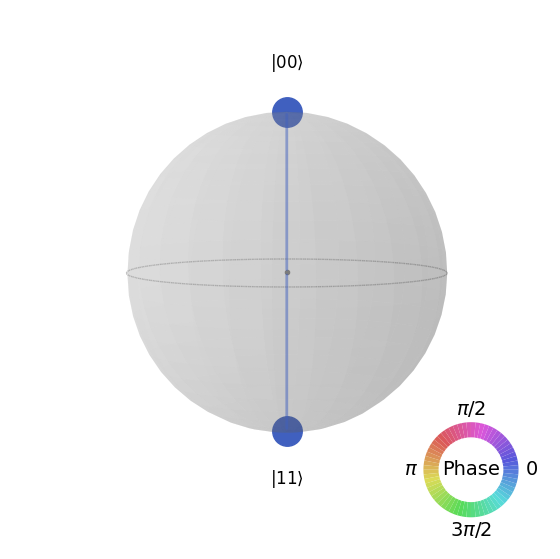

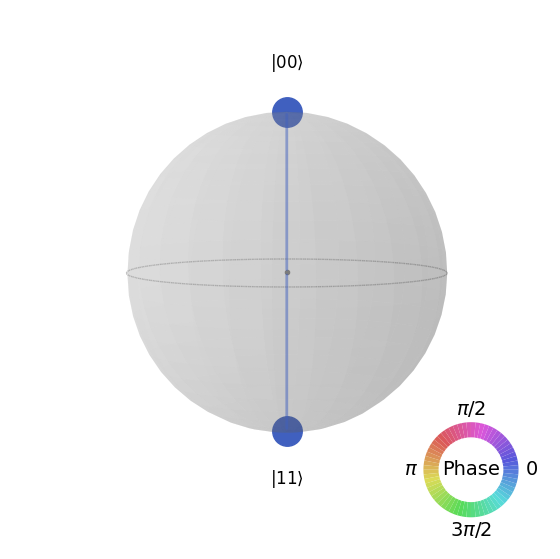

In [16]:
# Sphere 

plot_state_qsphere(sv)

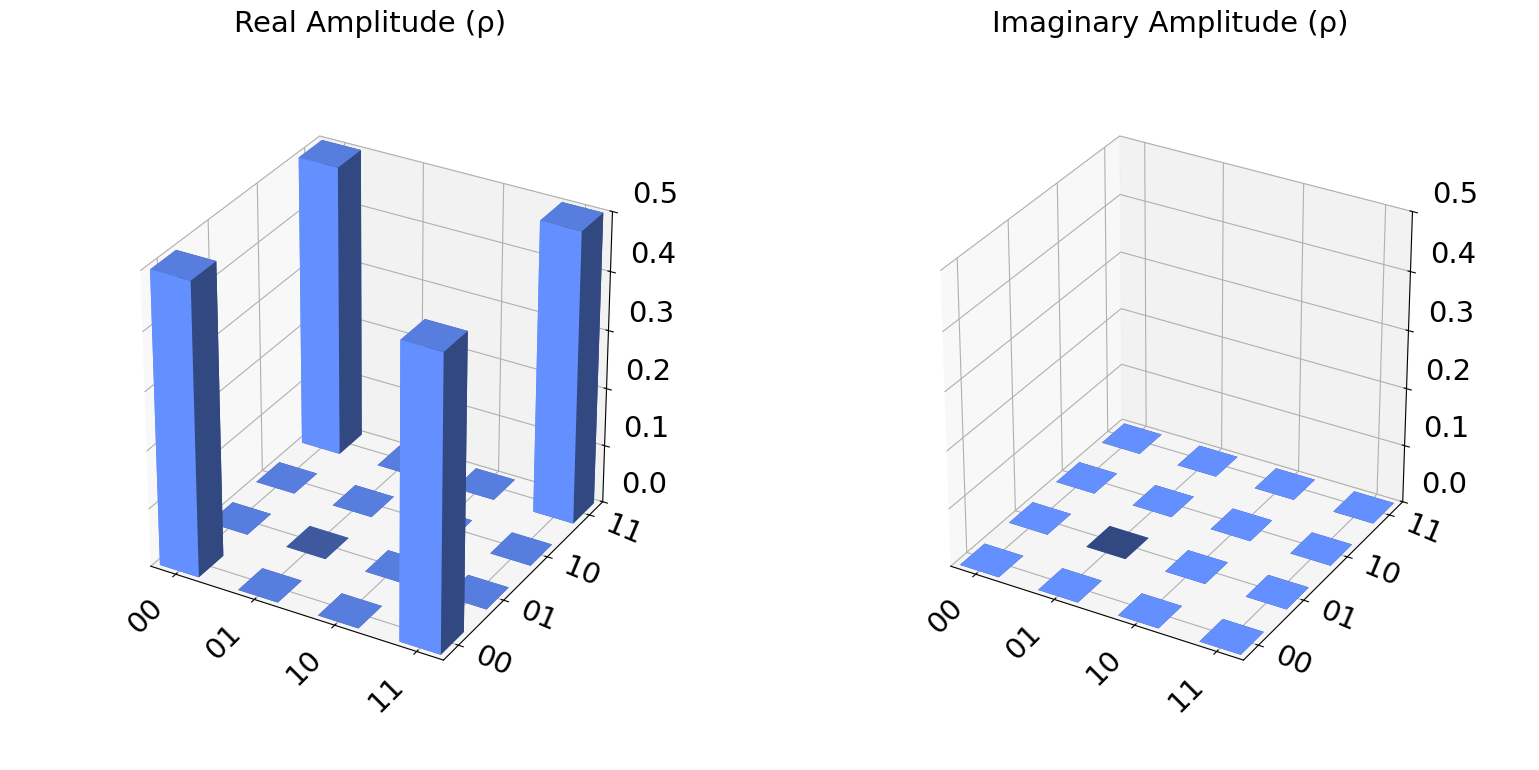

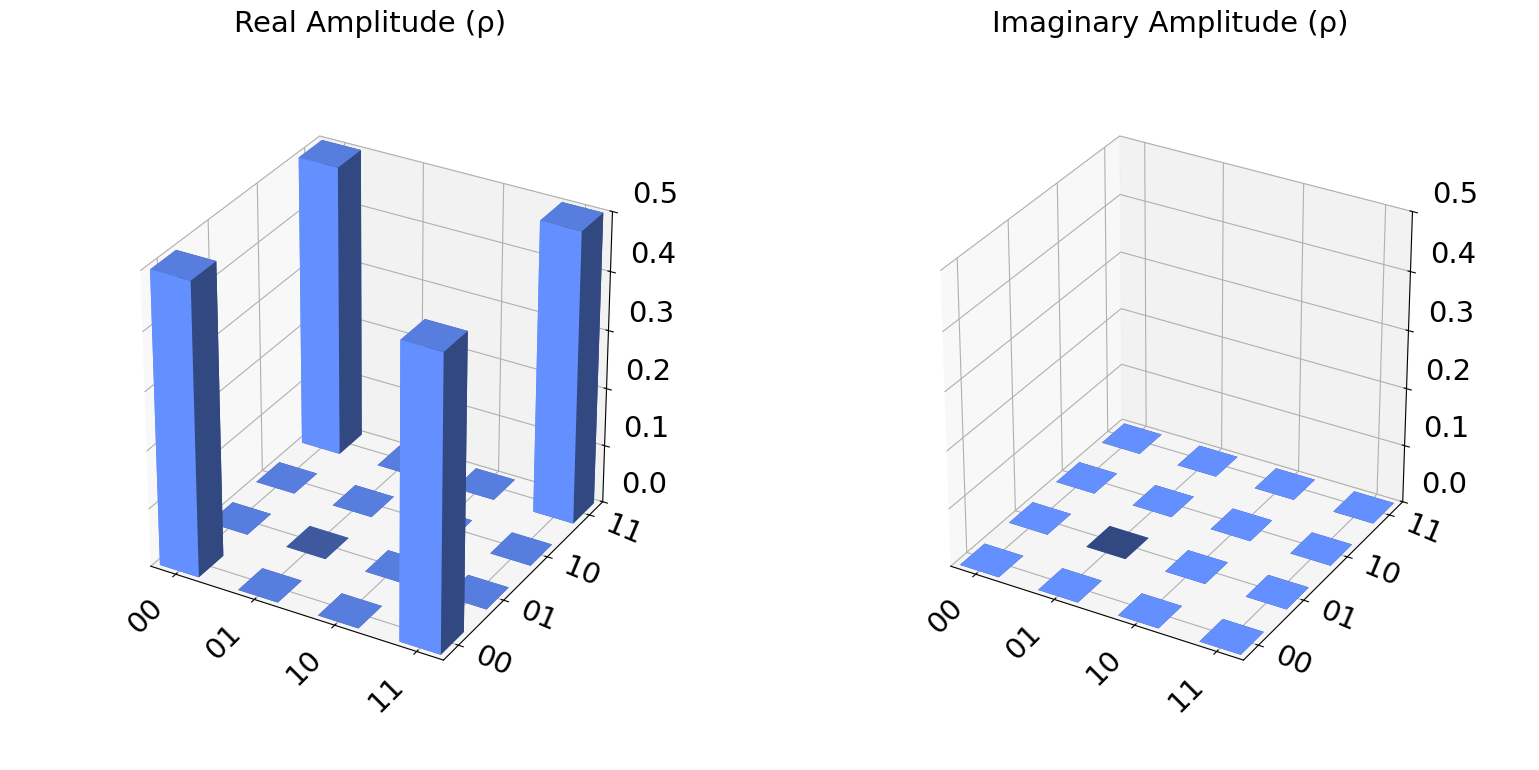

In [17]:
# Plot Histogram

plot_state_city(sv)

Density Matrix (밀도 행렬)

density matrix는 양자 상태를 확률 + 간섭(phase)까지 포함하여 표현하는 행렬이며, 상태들 간 관계(간섭 + 확률)를 포함한 구조적 표현

**StateVector vs Density Matrix**

| 개념 | statevector | density matrix |
| -- | ----------- | -------------- |
| 표현 | 하나의 상태      | 상태들의 관계        |
| 구조 | 벡터          | 행렬             |
| 정보 | 확률 진폭       | 확률 + 간섭        |

**Density Matrix**
| 요소 | 의미 |
|------|------|
| diagonal | 확률 |
| off-diagonal | 간섭 / 위상 / 얽힘 |
| 전체 | 양자 상태 전체 구조 |

Bell State 측정 결과: {'11': 519, '00': 505}
값이 정확하게 1/2, 1/2이지 않은 이유는 통계적 결과이기 때문입니다.



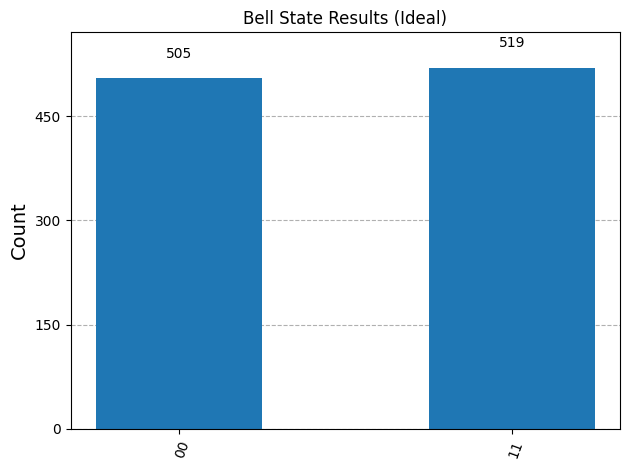

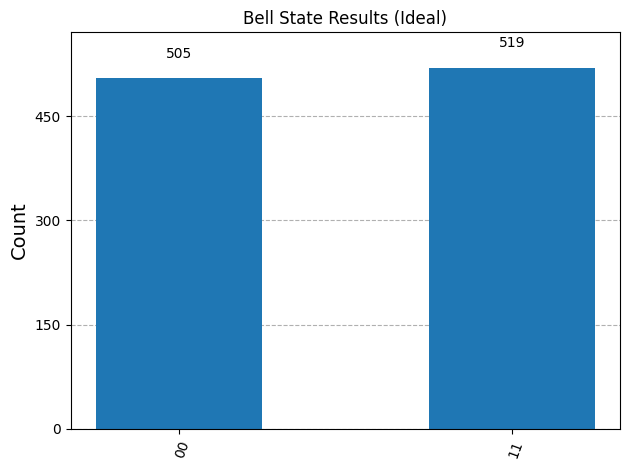

In [18]:
# 측정 및 결과 확인

qc_bell.measure_all()
job_bell = local_sim.run(transpile(qc_bell, local_sim), shots=1024)
counts_bell = job_bell.result().get_counts()

print(f"Bell State 측정 결과: {counts_bell}")
print("값이 정확하게 1/2, 1/2이지 않은 이유는 통계적 결과이기 때문입니다.\n")
plot_histogram(counts_bell, title="Bell State Results (Ideal)")

In [19]:
# 확장형 GHZ 회로 생성 및 시뮬레이션
# 함수를 통해 N-큐비트로 확장하고, 시뮬레이션 전 상태를 분석합니다.

# 1. 큐비트 수 설정
N_QUBITS = 3

# 2. GHZ 회로 생성 함수 (확장형)
def create_ghz_circuit(n):
    qc = QuantumCircuit(n)
    qc.h(0)  # 시작점: 첫 번째 큐비트에 중첩 생성
    for i in range(n - 1):
        qc.cx(i, i + 1)  # 순차적 얽힘 전파
    return qc

ghz_qc = create_ghz_circuit(n=N_QUBITS)
print(f"{N_QUBITS}-Qubit GHZ 회로 설계 완료")

3-Qubit GHZ 회로 설계 완료


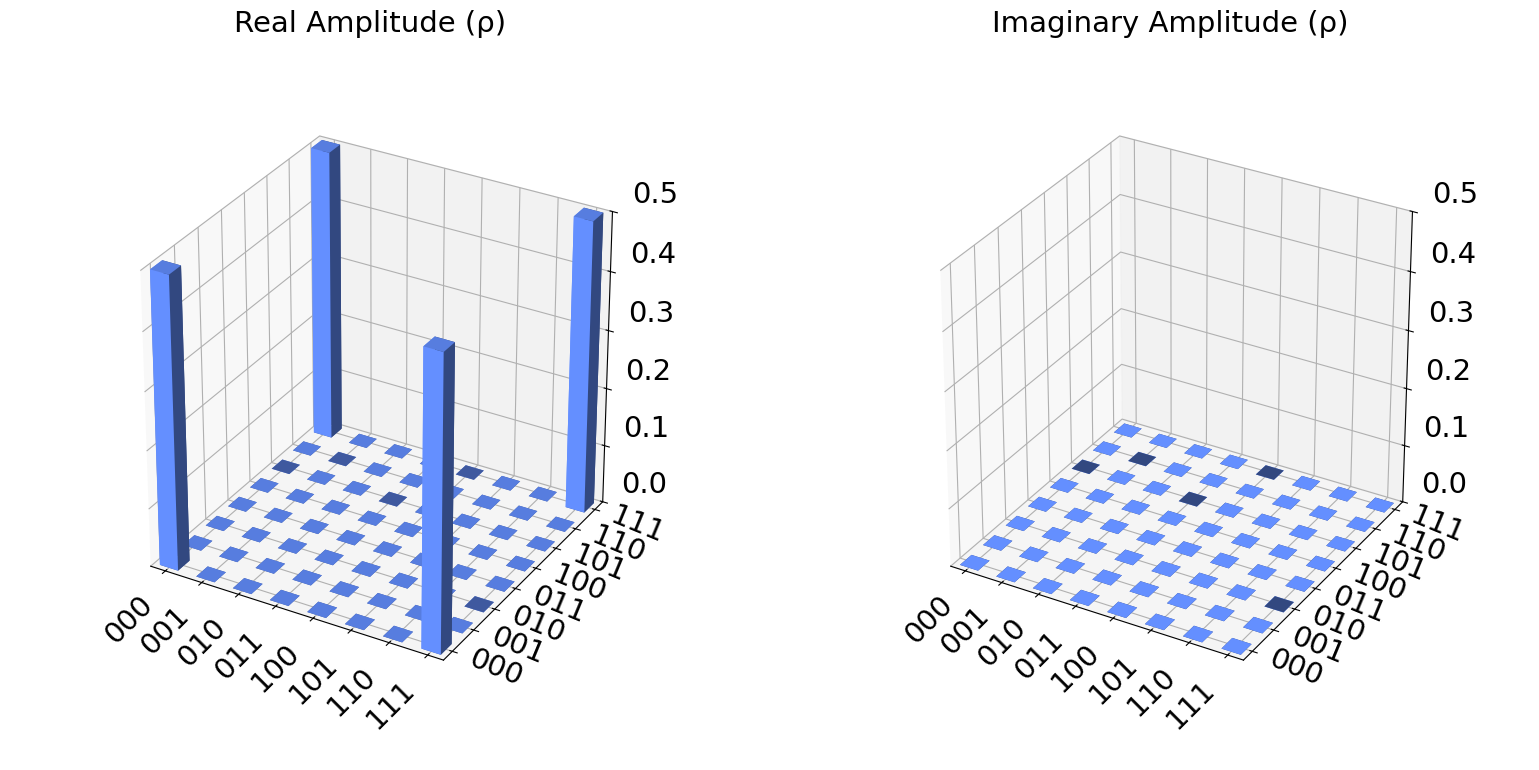

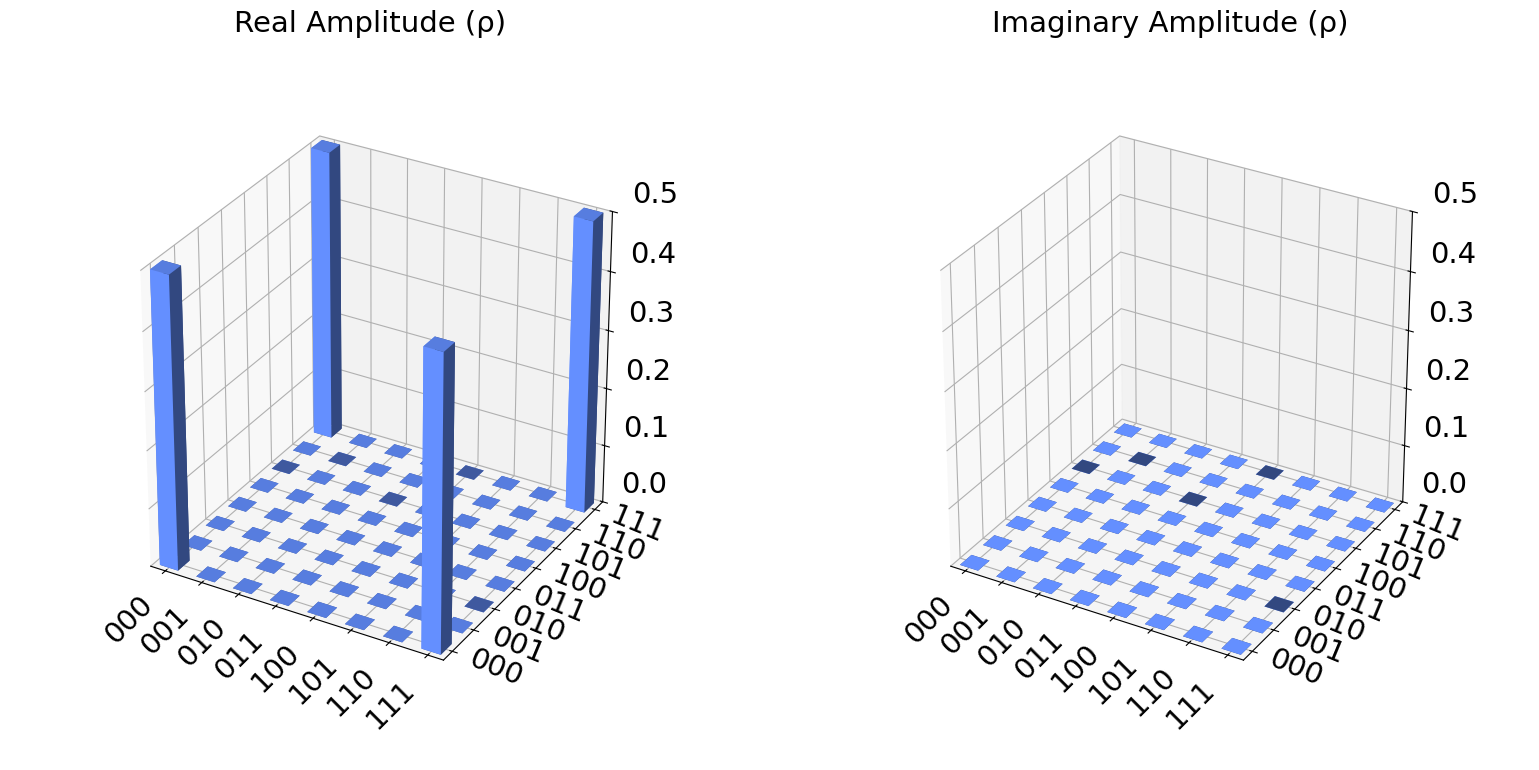

In [20]:
sv = Statevector.from_instruction(ghz_qc)
num_qubits = sv.num_qubits

plot_state_city(sv)

AWS SV1 시뮬레이터로 작업을 전송합니다...
AWS SV1 측정 데이터: {'000': 481, '111': 519}


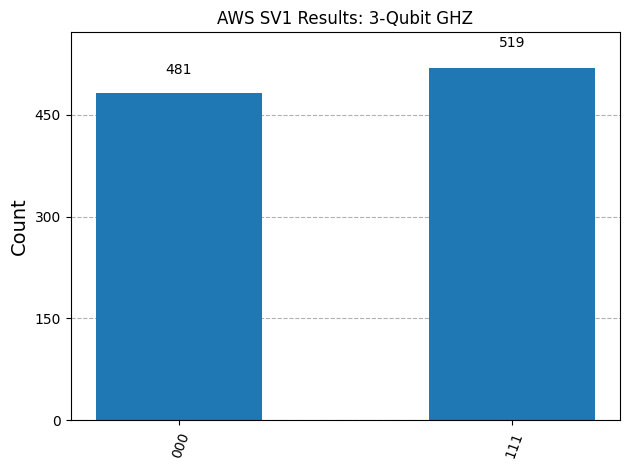

CPU times: user 966 ms, sys: 187 ms, total: 1.15 s
Wall time: 6.45 s


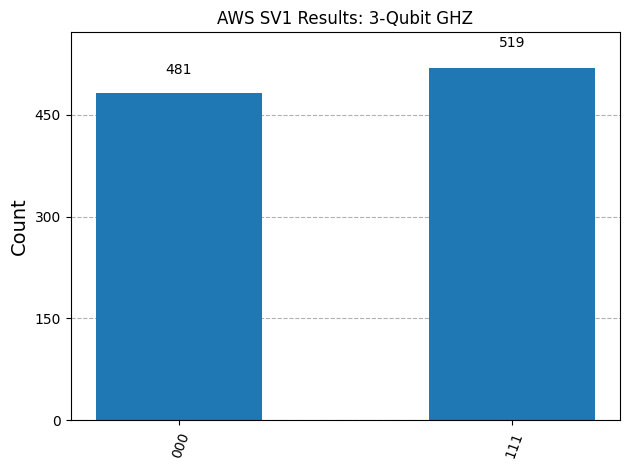

In [21]:
%%time

# =========================
# AWS SV1 Execution
# =========================
try:
    provider = BraketProvider()
    backend = provider.get_backend("SV1")

    # transpile
    t_qc = transpile(ghz_qc, backend, optimization_level=0)

    print("AWS SV1 시뮬레이터로 작업을 전송합니다...")

    job = backend.run(t_qc, shots=1000)
    result = job.result()
    counts = result.get_counts()

    print(f"AWS SV1 측정 데이터: {counts}")

    display(
        plot_histogram(
            counts,
            title=f"AWS SV1 Results: {N_QUBITS}-Qubit GHZ"
        )
    )

# =========================
# Fallback (Local Simulator)
# =========================
except Exception as e:
    print(f"AWS 연결 오류: {e}")
    print("로컬 시뮬레이터 결과를 대신 표시합니다.")

    t_local = transpile(ghz_qc, local_sim)

    result = local_sim.run(t_local, shots=1024).result()
    counts = result.get_counts()

    display(
        plot_histogram(
            counts,
            title="Local Simulator Results (Fallback)"
        )
    )

✔ W-state

$$|\psi_{W}\rangle = \frac{1}{\sqrt{3}}(|001\rangle + |010\rangle+ |100\rangle)$$

* W-state는 “한 개의 1이 여러 큐비트에 분산된 얽힘 상태”입니다. 

| 특징       | GHZ       | W-state         |
| -------- | --------- | --------------- |
| 구조       | 000 + 111 | 100 + 010 + 001 |
| 얽힘 성격    | fragile   | robust          |
| 한 큐비트 측정 | 전체 붕괴     | 일부 유지           |
| 정보       | global    | distributed     |


In [22]:
# 얽힘의 견고함 테스트 (GHZ vs W)
# 큐비트 손실 상황을 시뮬레이션하여 두 상태의 차이를 데이터로 비교합니다.

def test_robustness(circuit, name):
    # 큐비트 하나(q0)를 측정하여 강제로 상태를 붕괴시킴
    test_qc = circuit.copy()
    test_qc.measure_all()
    # 100번 실행하여 통계 확인
    result = local_sim.run(transpile(test_qc, local_sim), shots=10000).result()
    counts = result.get_counts()
    print(f"[{name} 측정 결과]: {counts}")

# GHZ 테스트 (ghz_qc는 Cell 15에서 생성됨)
test_robustness(ghz_qc, "GHZ State")


[GHZ State 측정 결과]: {'111': 4945, '000': 5055}


In [23]:
from qiskit import QuantumCircuit
import numpy as np

def create_w_state_3q():
    qc = QuantumCircuit(3)

    # -----------------------------
    # 1. q0에 amplitude 일부 할당
    # P(q0=1) = 1/3
    # -----------------------------
    qc.ry(2 * np.arcsin(np.sqrt(1/3)), 0)

    # -----------------------------
    # 2. q0 → q1 분배
    # -----------------------------
    qc.cx(0, 1)
    qc.cry(2 * np.arcsin(np.sqrt(1/2)), 0, 1)
    qc.cx(0, 1)

    # -----------------------------
    # 3. q0 → q2 분배
    # -----------------------------
    qc.cx(0, 2)
    qc.cry(2 * np.arcsin(np.sqrt(1/2)), 0, 2)
    qc.cx(0, 2)

    # “q0에 있던 단일 excitation을 q1, q2로 확률적으로 분배한 상태”이다.

    return qc
    
# W-상태 테스트 (w_circuit은 create_w_state_3q()를 통해 생성)
w_circuit = create_w_state_3q()

test_robustness(w_circuit, "W-State")

[W-State 측정 결과]: {'101': 841, '111': 821, '011': 842, '000': 6699, '001': 797}


* GHZ vs W (교육용 핵심)

| 상태  | 구조              | 특징                     |
| --- | --------------- | ---------------------- |
| GHZ | 000 + 111       | all-or-nothing         |
| W   | 100 + 010 + 001 | distributed excitation |


--- 15-Qubit GHZ 회로 정보 ---
회로 깊이(Depth): 15

AWS SV1 측정 데이터: {'111111111111111': 508, '000000000000000': 492}



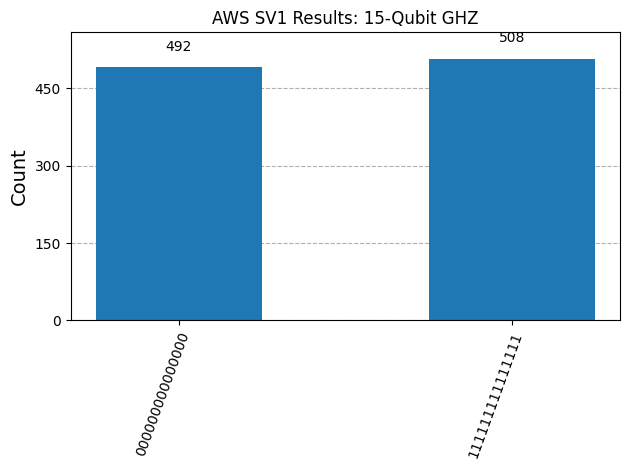

CPU times: user 290 ms, sys: 19.3 ms, total: 310 ms
Wall time: 2.01 s


In [24]:
%%time

'''
목적: 양자 컴퓨터 확장성
과제: N_QUBITS 변수를 15 또는 그 이상(최대 25 권장)으로 설정하고 작업을 제출하세요.

큐비트 수가 늘어남에 따라 회로의 깊이(Depth)와 복잡도가 어떻게 변하는지 관찰합니다.
AWS Braket 콘솔에서 작업 완료까지 걸리는 시간(Execution Time)을 체크해 보세요.
측정 결과에서 00...0과 11...1만 정확히 검출되는지 확인합니다.
'''

# 미션 1: 대규모 GHZ 회로 생성 및 AWS 제출
LARGE_N = 15  # 15개 이상의 큐비트 설정
ghz_large = create_ghz_circuit(LARGE_N)

print(f"--- {LARGE_N}-Qubit GHZ 회로 정보 ---")
print(f"회로 깊이(Depth): {ghz_large.depth()}\n")

# AWS SV1 백엔드 호출 및 실행 (AWS 설정이 완료된 경우 주석 해제)
t_qc_large = transpile(ghz_large, backend)
job_large = backend.run(t_qc_large, shots=1000)

result = job_large.result()
counts = result.get_counts()

print(f"AWS SV1 측정 데이터: {counts}\n")

fig = plot_histogram(
    counts,
    title=f"AWS SV1 Results: {LARGE_N}-Qubit GHZ"
)

plt.show()
plt.close(fig)

In [25]:
%matplotlib inline

'''
목적: 제어 정밀도
과제: theta 값을 조정하여 확률 변화를 확인해보세요. 
'''

def create_param_ghz(theta):
    qc = QuantumCircuit(3)

    # ---------------------------------
    # 1. amplitude split
    # ---------------------------------
    qc.ry(theta, 0)

    # ---------------------------------
    # 2. entanglement propagation
    # ---------------------------------
    qc.cx(0, 1)
    qc.cx(1, 2)

    qc.measure_all()

    return qc


def interactive_ghz(theta):

    qc = create_param_ghz(theta)

    counts = local_sim.run(
        transpile(qc, local_sim),
        shots=1024
    ).result().get_counts()

    sorted_counts = dict(sorted(counts.items(), key=lambda x: int(x[0], 2)))
    print(f'출력 결과: {sorted_counts}')

    # theory
    p0 = np.cos(theta/2)**2
    p1 = np.sin(theta/2)**2

    print(f"이론값: |000>: {p0*100:.2f}%, |111>: {p1*100:.2f}%\n")
    
    fig = plot_histogram(counts, figsize=(8,4))
    plt.show()
    plt.close(fig)
    
# 인터랙티브 슬라이더 실행 (0부터 2pi까지 제어)
interact(interactive_ghz, 
         theta=FloatSlider(min=0, max=np.pi*2, step=0.1, value=np.pi/3, description='Rotation θ:'));

interactive(children=(FloatSlider(value=1.0471975511965976, description='Rotation θ:', max=6.283185307179586),…

### E.O.D.